# GIF — Respiratory signal + k-space phase ramp + reconstructed image

3-panel animation over 30 seconds of acquisition:
- Top-left: respiratory signal with sampling points appearing one by one
- Bottom-left: k-space building up with phase ramp visible
- Right: reconstructed image updating progressively

In [7]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nibabel as nib
import json
import io
import neurokit2 as nk
from pathlib import Path
from PIL import Image
from scipy.interpolate import interp1d

project_root = Path("..").resolve()
sys.path.append(str(project_root))

from src import Kspace_simulation
import importlib
importlib.reload(Kspace_simulation)
from src.Kspace_simulation import load_slice

PROJECT_ROOT = Path('/Users/annaellesarrazin/Sarrazin_project')
DATASET_DIR  = PROJECT_ROOT / 'ds005616'
SPLITS_PATH  = PROJECT_ROOT / 'training_data' / 'splits.json'
GIF_DIR      = PROJECT_ROOT / 'gif'
GIF_DIR.mkdir(parents=True, exist_ok=True)

with open(SPLITS_PATH) as f:
    splits = json.load(f)

sub_id   = splits['val'][0]
nii_path = DATASET_DIR / f'sub-{sub_id}' / 'anat' / f'sub-{sub_id}_T2w.nii.gz'
volume   = nib.load(nii_path).get_fdata(dtype=np.float32)
image    = load_slice(volume, slice_idx=25, axis=0).copy()
# image = np.rot90(load_slice(volume, slice_idx=25, axis=0), k=-1).copy()
ny, nx = image.shape
print(f'After rotation — ny={ny}, nx={nx}')

print(f'Subject : {sub_id} | Slice shape : {image.shape}')

After rotation — ny=394, nx=657
Subject : unfPain006 | Slice shape : (394, 657)


In [8]:
# ── Parameters ────────────────────────────────────────────────────
A   = 5.0   # amplitude (px)
F   = 15    # respiratory rate (breaths/min)
TR  = 1.5   # repetition time (s)
TE  = 0.119 # echo time (s)

ny, nx = image.shape
duration_total = ny * TR  # total acquisition time

# ── Generate respiratory signal at 100 Hz ─────────────────────────
sampling_rate = 100
rsp_raw = nk.rsp_simulate(
    duration=int(duration_total),
    sampling_rate=sampling_rate,
    respiratory_rate=F,
    method='breathmetrics',
    random_state=42
)
t_full   = np.linspace(0, duration_total, len(rsp_raw))
rsp_norm = rsp_raw / (np.max(np.abs(rsp_raw)) + 1e-8)

# ── Sample at each k-space line ────────────────────────────────────
t_ky     = np.arange(ny) * TR + TE
interp_f = interp1d(t_full, rsp_norm, kind='linear', fill_value='extrapolate')
rsp_ky   = interp_f(t_ky)
displ    = A * rsp_ky  # displacement in pixels per ky line

# ── Pre-compute clean and corrupted k-spaces ──────────────────────
clean_kspace = np.fft.fftshift(np.fft.fft2(image))
kx_freq      = np.fft.fftshift(np.fft.fftfreq(nx))

phase_ramps = np.exp(
    -1j * 2 * np.pi
    * displ[:, np.newaxis]
    * kx_freq[np.newaxis, :]
)
corrupted_kspace = clean_kspace * phase_ramps

print(f'K-space shape : {clean_kspace.shape}')
print(f'Acquisition duration : {duration_total:.0f}s over {ny} lines')

K-space shape : (394, 657)
Acquisition duration : 591s over 394 lines


In [9]:
def fig_to_pil(fig, dpi=90):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi,
                bbox_inches='tight', facecolor='white')
    buf.seek(0)
    img = Image.open(buf).copy()
    buf.close()
    plt.close(fig)
    return img


def reconstruct_partial(kspace_full, n_lines):
    """iFFT on partial k-space (only first n_lines acquired)."""
    partial = np.zeros_like(kspace_full)
    partial[:n_lines, :] = kspace_full[:n_lines, :]
    return np.abs(np.fft.ifft2(np.fft.ifftshift(partial)))


# ── Determine frames to render ────────────────────────────────────
# We want ~30s of GIF at ~12fps → 360 frames
# But rendering all ny lines is slow — subsample
N_FRAMES = 60  # number of unique frames (then we'll set duration to match 30s)
line_indices = np.unique(np.round(
    np.linspace(1, ny, N_FRAMES)
).astype(int))

# Duration per frame so total GIF ≈ 30s
ms_per_frame = int(30000 / len(line_indices))

print(f'Rendering {len(line_indices)} frames — {ms_per_frame}ms each → ~30s GIF')

Rendering 60 frames — 500ms each → ~30s GIF


In [10]:
# ── Pre-compute all reconstructions (slow step) ───────────────────
print('Pre-computing reconstructions...')
recons = {}
for n in line_indices:
    recons[n] = reconstruct_partial(corrupted_kspace, n)
    if n % 10 == 0:
        print(f'  line {n}/{ny}')
print('Done.')

Pre-computing reconstructions...
Done.


In [ ]:
# ── Render frames ─────────────────────────────────────────────────
frames = []

# Color constants
COL_SIGNAL   = "#0C96B8A1"
COL_ACQUIRED = "#F79809EC"
COL_CURRENT  = '#E24B4A'
COL_PENDING  = '#D3D1C7'

# Fixed display window: show last 30s of signal
WINDOW = 30.0  # seconds

for n_lines in line_indices:
    t_now = t_ky[n_lines - 1]  # current acquisition time
    t_win_start = max(0, t_now - WINDOW)

    fig = plt.figure(figsize=(10, 6))
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        width_ratios=[1, 1],
        height_ratios=[1, 1],
        wspace=0.1, hspace=0.25
    )

    ax1 = fig.add_subplot(gs[0, 0])   # haut gauche  — signal respiratoire
    ax2 = fig.add_subplot(gs[1, 0])   # bas gauche   — k-space
    ax3 = fig.add_subplot(gs[:, 1])   # droite entier — image reconstruite

    # ── Panel 1: Respiratory signal ───────────────────────────

    # Mask signal to display window
    mask_full = (t_full >= t_win_start) & (t_full <= t_now)
    ax1.plot(
        t_full[mask_full] - t_win_start,
        rsp_norm[mask_full] * A,
        color=COL_SIGNAL, linewidth=1.8, zorder=1
    )

    # Acquired sampling points in window
    mask_ky = (t_ky[:n_lines] >= t_win_start) & (t_ky[:n_lines] <= t_now)
    t_ky_win    = t_ky[:n_lines][mask_ky] - t_win_start
    displ_win   = displ[:n_lines][mask_ky]

    if len(t_ky_win) > 1:
        ax1.scatter(
            t_ky_win[:-1], displ_win[:-1],
            color=COL_ACQUIRED, s=20, zorder=3
        )

    # Current point
    ax1.scatter(
        [t_now - t_win_start], [displ[n_lines - 1]],
        color=COL_CURRENT, s=60, zorder=4
    )

    # Zero line
    ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

    # Phase displacement annotation
    if n_lines > 0:
        d_current = displ[n_lines - 1]
        # color = '#E24B4A' if abs(d_current) > A*0.5 else '#1D9E75'
        color = '#E24B4A' if d_current < 0 else '#1D9E75'
        ax1.text(0.02, 0.02,
                 f'd = {d_current:.1f} px',
                 transform=ax1.transAxes,
                 fontsize=10, color=color,
                 bbox=dict(facecolor='white', alpha=0.7,
                           edgecolor='none', pad=2))

    ax1.set_xlim(0, WINDOW)
    ax1.set_ylim(-A * 1.35, A * 1.35)
    ax1.set_xlabel('Time (s)', fontsize=10)
    ax1.set_ylabel('Displacement (px)', fontsize=10)
    ax1.set_title(
        f'Respiratory signal  |  ky = {n_lines}/{ny}  ',
        fontsize=10
    )
    ax1.spines[['top', 'right']].set_visible(False)

    # Amplitude bracket
    ax1.annotate(
        '', xy=(WINDOW * 0.97, A), xytext=(WINDOW * 0.97, 0),
        arrowprops=dict(arrowstyle='<->', color='#E24B4A', lw=1.2)
    )

    ax1.text(
        WINDOW * 0.97, A + 0.3,
        f'A={A}px', fontsize=8,
        color='#A32D2D', va='bottom', ha='center'
        )

    # ── Panel 2: K-space magnitude ────────────────────────────
    kspace_partial = np.zeros_like(corrupted_kspace)
    kspace_partial[:n_lines, :] = corrupted_kspace[:n_lines, :]
    log_mag = np.log1p(np.abs(kspace_partial))

    ax2.imshow(log_mag, cmap='gray', origin='upper', aspect='auto')
    ax2.set_xlim(0, nx)   # 657
    ax2.set_ylim(ny, 0)   # 394, inversed because origin='upper'

    # Frontière horizontale qui descend
    if n_lines < ny:
        ax2.axhline(n_lines, color=COL_CURRENT,
                    linewidth=1.5, linestyle='--')
        ax2.fill_between(
            [0, nx],           # ← largeur du k-space (657)
            [n_lines, n_lines],
            [ny, ny],          # ← hauteur restante (394)
            color='black', alpha=0.55
        )

    ax2.text(0.5, -0.02, 'K-space', fontsize=10, ha='center', va='top', transform=ax2.transAxes)
    ax2.axis('off')

    # ── Panel 3: Reconstructed image ──────────────────────────

    img_rec = recons[n_lines]
    vmin, vmax = np.percentile(img_rec, (1, 99))
    ax3.imshow(np.rot90(img_rec, k=-1), cmap='gray', origin='lower', aspect='equal', vmin=vmin, vmax=vmax)
    ax3.set_title('Reconstructed image', fontsize=10)
    ax3.axis('off')

    # Progress badge
    pct = int(100 * n_lines / ny)
    ax3.text(
        0.97, 0.03, f'{pct}%',
        transform=ax3.transAxes,
        fontsize=9, color='white', ha='right',
        bbox=dict(facecolor=COL_ACQUIRED, alpha=0.8,
                  edgecolor='none', pad=2)
    )

    plt.tight_layout(pad=0.8)
    frames.append(fig_to_pil(fig, dpi=100))

# Hold last frame for 3s
n_hold = max(1, int(3000 / ms_per_frame))
frames += [frames[-1]] * n_hold

out_path = GIF_DIR / 'gif_realtime_acquisition.gif'
frames[0].save(
    out_path,
    save_all=True,
    append_images=frames[1:],
    duration=ms_per_frame,
    loop=0,
    optimize=True
)
print(f'Saved : {out_path}')
print(f'{len(frames)} frames × {ms_per_frame}ms = ~{len(frames)*ms_per_frame/1000:.0f}s')

/var/folders/wq/lytb6qh94sq_yp6sfgbzd8500000gn/T/ipykernel_71779/3450116671.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.8)


Saved : /Users/annaellesarrazin/Sarrazin_project/gif/gif_realtime_acquisition.gif
66 frames × 500ms = ~33s


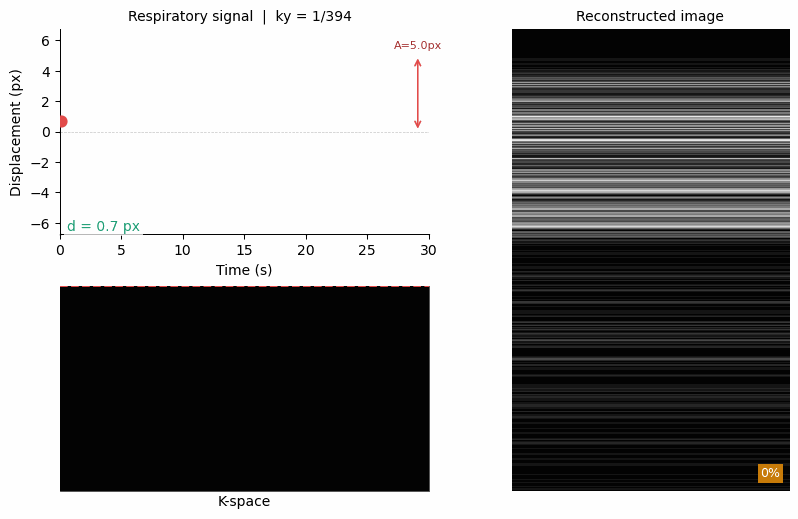

In [12]:
from IPython.display import Image as IPImage
IPImage(filename=str(GIF_DIR / 'gif_realtime_acquisition.gif'))